In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
import stableemrifisher
stableemrifisher.__file__

'/nfs/home/svu/e1498138/localgit/Fisher/StableEMRIFisher/stableemrifisher/__init__.py'

In [3]:
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher
from stableemrifisher.utils import inner_product

startup


In [4]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 2   # Total time

In [5]:
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

In [6]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [7]:
waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

In [8]:
gew_waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [9]:
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS   = np.pi / 3 
phiS = 0.
qK   = np.pi - qS + 0.01 
phiK = phiS + np.pi        
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5



In [10]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    print(R,S)
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [11]:
theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta*180/np.pi, phi

[0.8660254 0.        0.5      ] [-8.60982186e-01  1.05439908e-16 -5.08635110e-01]


(np.float64(0.5729577951309058), -1.5707963267948966)

In [12]:
from lisatools.sensitivity import get_sensitivity, CornishLISASens
sef = StableEMRIFisher(
    waveform_class=waveform_class,
    waveform_class_kwargs=waveform_class_kwargs,
    waveform_generator=waveform_generator,
    waveform_generator_kwargs=waveform_generator_kwargs,
    stats_for_nerds=True,
    use_gpu=use_gpu,
    deriv_type='stable',
    noise_model=get_sensitivity,
    noise_kwargs={'sens_fn': CornishLISASens, 'return_type': 'PSD'},
    channels=["A"]
)

# Fisher calculation parameters
der_order = 4
Ndelta = 8
stability_plot = False
param_names = ['m1', 'm2', 'a', 'p0', 'e0', 'dist', 'qS', 'phiS']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [13]:
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

T:  2 dt:  10
Body is not plunging, Fisher should be stable.
wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 11.7, 0.4, 1.0, 0.9, 1.0471975511965976, 0.0, 2.1043951023931955, 3.141592653589793, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 97.08568387184283
calculating stable deltas...
Gamma_ii for m1: 39503.808702633156
Gamma_ii for m1: 39503.80870351874
Gamma_ii for m1: 39503.80870354549
Gamma_ii for m1: 39503.80871154811
Gamma_ii for m1: 39503.80868737629
Gamma_ii for m1: 39503.80867124241
Gamma_ii for m1: 39503.808211559095
Gamma_ii for m1: 39503.81404646585
[np.float64(2.2417734748038087e-11), np.float64(6.770592777637101e-13), np.float64(2.0257849341721205e-10), np.float64(6.118858760999351e-10), np.float64(4.084131708662419e-10), np.float64(1.1636430452841097e-08), np.float64(1.4770489624205918e-07)]
1
Gamma_ii for m2: 4349129451213.967
Gamma_ii for m2: 4349129451214.2124
Gamma_ii for m2: 4349129450868.5063
Gamma_ii for m2: 4349129445971.1084
Gamma_ii for m2: 4349129

In [14]:
Fisher.shape

(8, 8)

In [15]:
import pickle
with open('unscaledfisher_snr97_ext.pkl', 'wb') as f:
    pickle.dump(Fisher, f)

In [16]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(8)
J_mx[0, 0] = m1
J_mx[1, 1] = m2
J_mx[6, 6] = 1/np.sin(qS)

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 36 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >]], dtype=object))

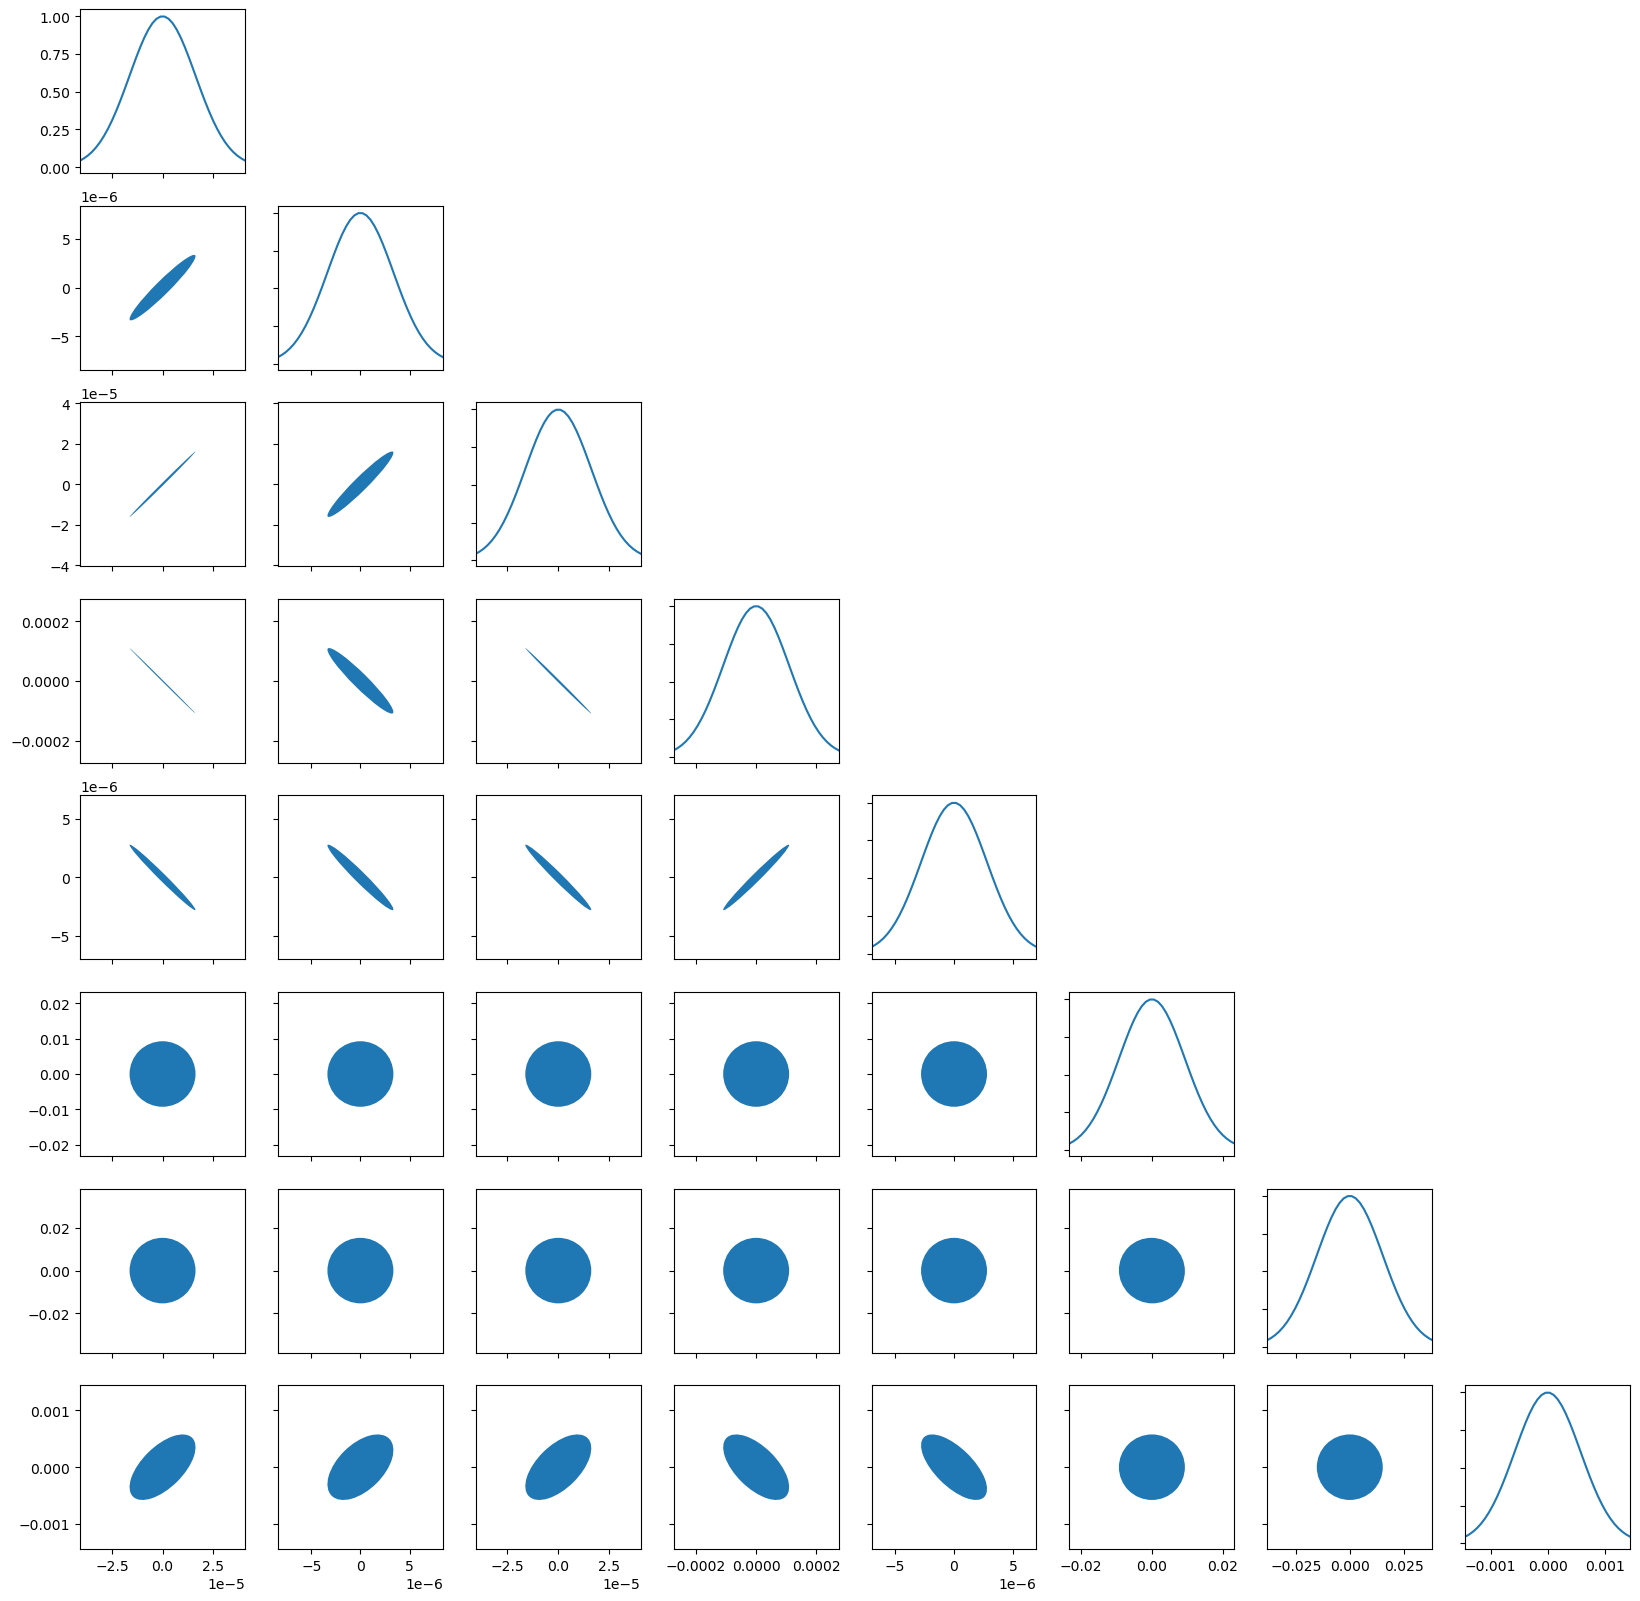

In [17]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [18]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 2.70596326e-10,  5.28478953e-11,  2.66072348e-10,
        -1.80544130e-09, -4.54811178e-11,  1.43932100e-10,
         6.38908734e-12,  5.79259326e-09],
       [ 5.28478953e-11,  1.12782306e-11,  5.20974710e-11,
        -3.50172060e-10, -9.13163402e-12,  2.95516879e-11,
         2.02524436e-12,  1.00872567e-09],
       [ 2.66072348e-10,  5.20974710e-11,  2.62224614e-10,
        -1.77593155e-09, -4.45097918e-11,  1.41986021e-10,
         7.11798210e-12,  5.41570343e-09],
       [-1.80544130e-09, -3.50172060e-10, -1.77593155e-09,
         1.20540230e-08,  3.02384521e-10, -9.57134941e-10,
        -4.20214359e-11, -3.84944194e-08],
       [-4.54811178e-11, -9.13163402e-12, -4.45097918e-11,
         3.02384521e-10,  7.82089028e-12, -2.44376633e-11,
        -1.00335938e-12, -1.07273404e-09],
       [ 1.43932100e-10,  2.95516879e-11,  1.41986021e-10,
        -9.57134941e-10, -2.44376633e-11,  8.59537722e-05,
        -2.03822983e-06,  2.73572698e-09],
       [ 6.38908734e-12,  2.025244

In [31]:
import pickle
with open('cov_matrix_snr97_ext2.pkl', 'wb') as f:
    pickle.dump(cov, f)

# Check Waveform

In [20]:
params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]


In [21]:
h = gew_waveform_gen(*params, T=T, dt=dt)


In [22]:
gwf.rhostat(h)

array(97.08568387)

In [28]:
h_short = gew_waveform_gen(*params, T=3/12, dt=dt)


In [29]:
gwf_short = GWfuncs.GravWaveAnalysis(T=3/12,dt=10)

In [30]:
gwf_short.rhostat(h_short)

array(10.71500452)